Group comparison: 100%|██████████| 1276/1276 [00:03<00:00, 416.48it/s]


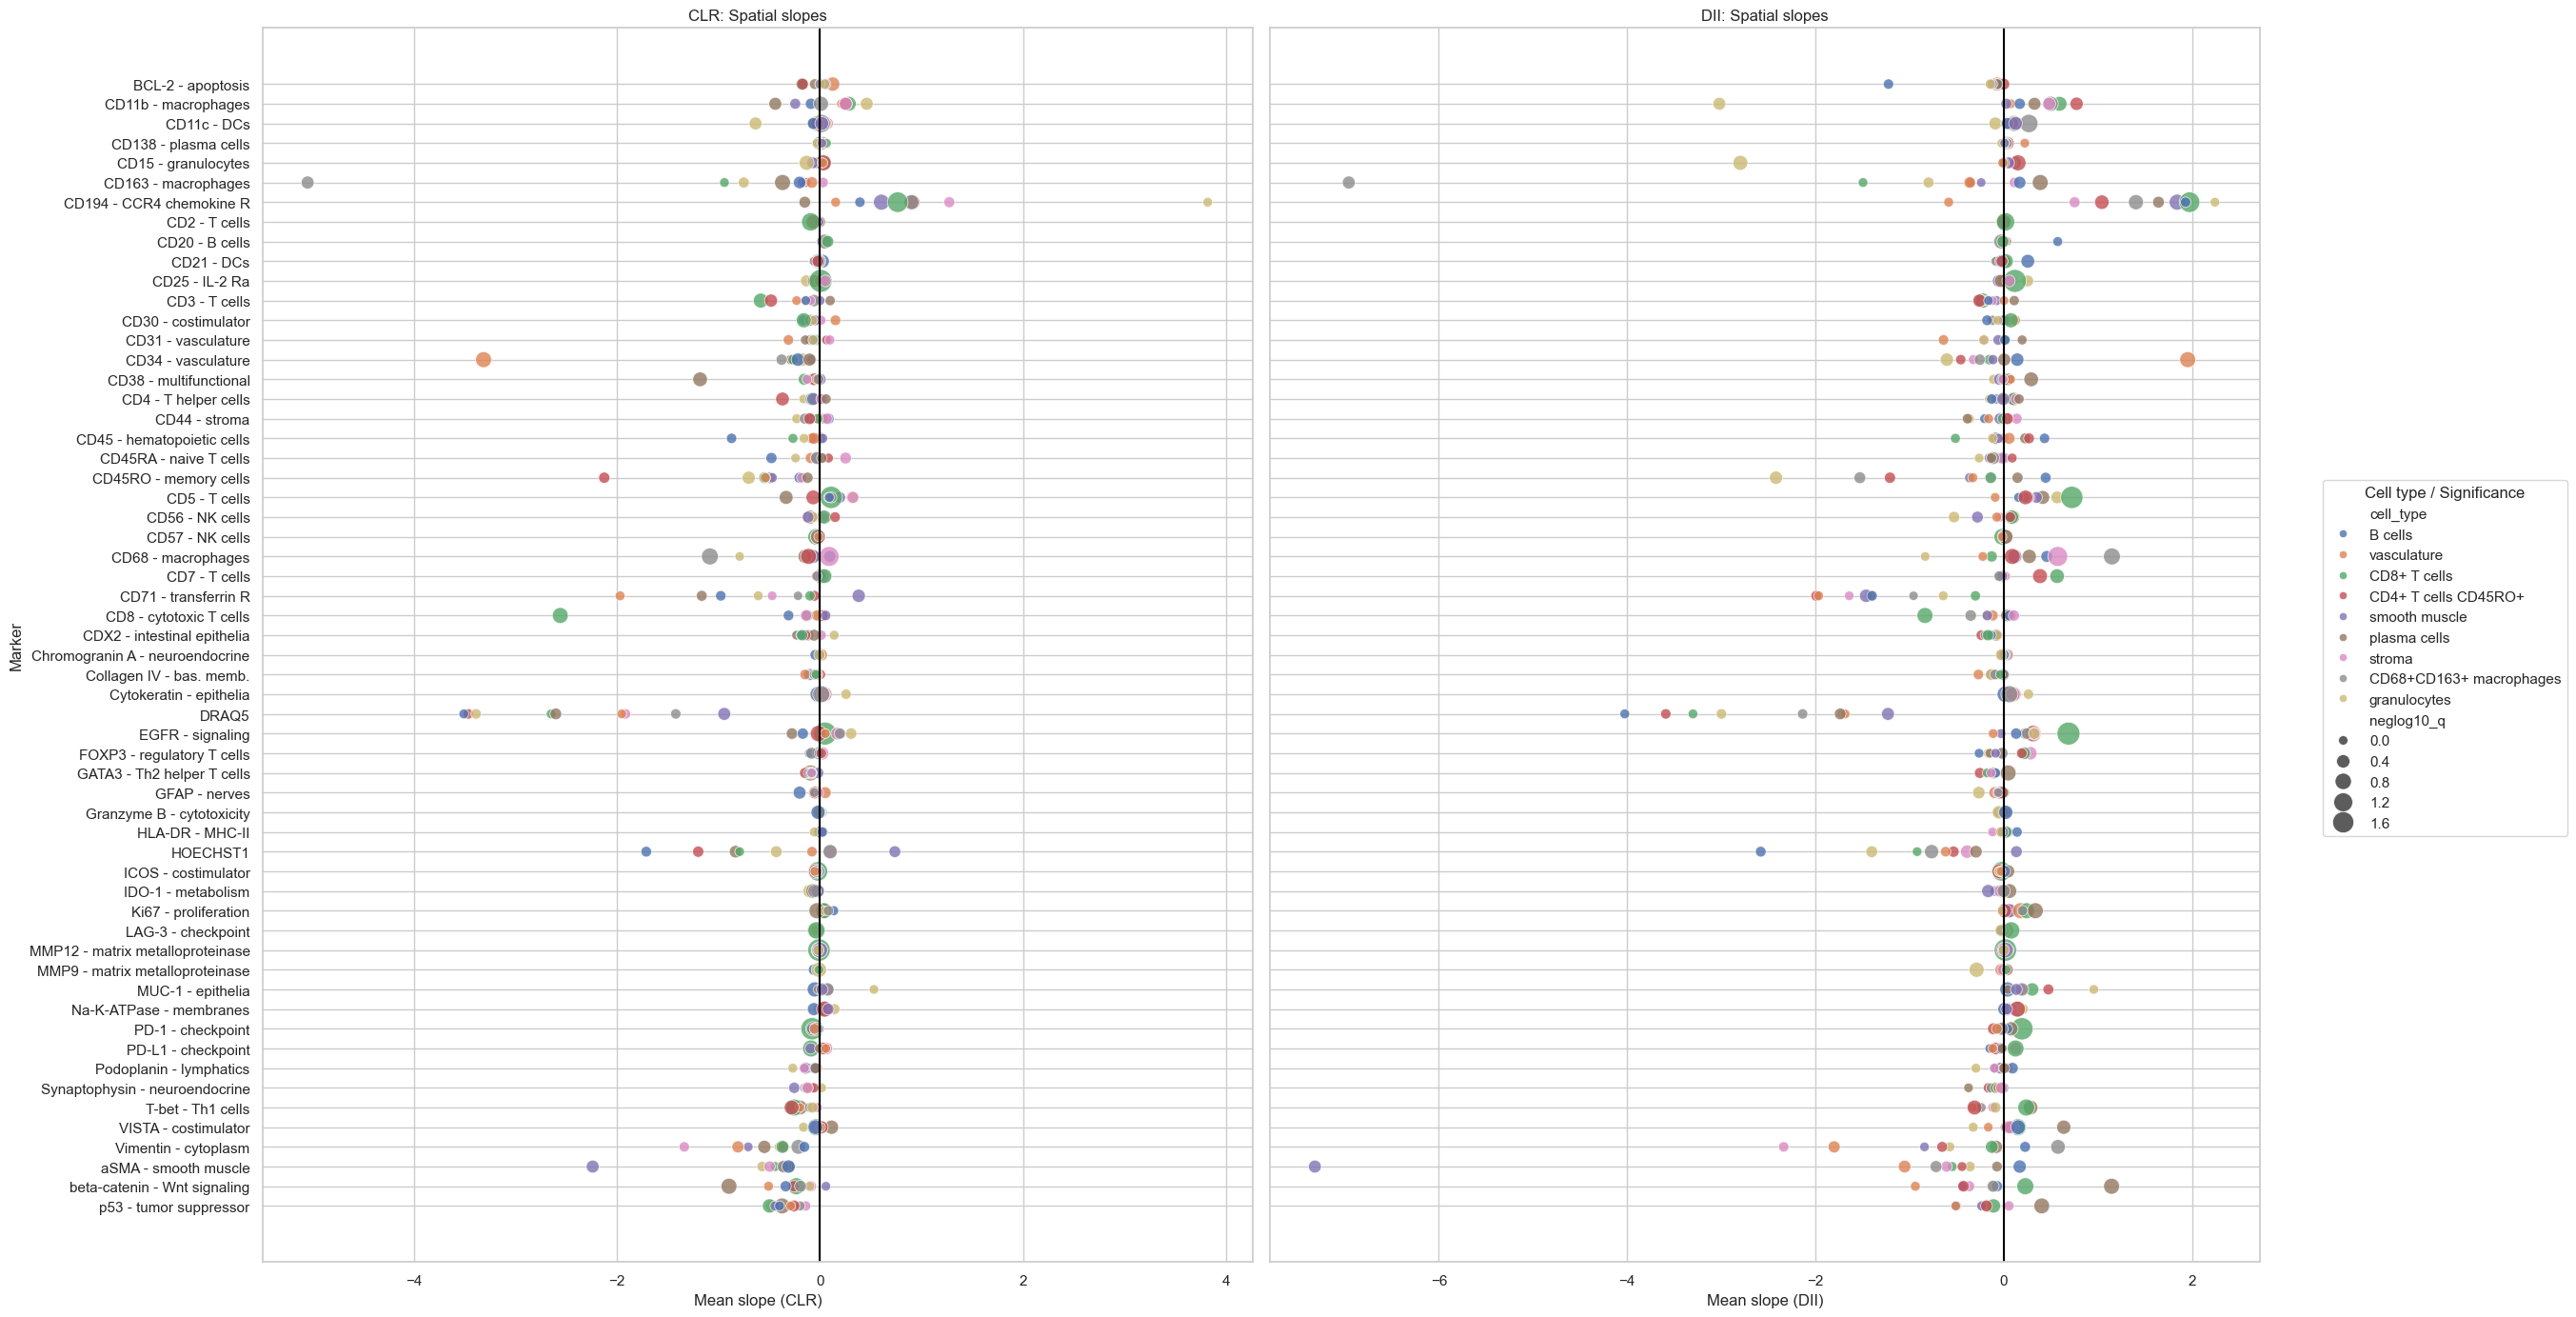

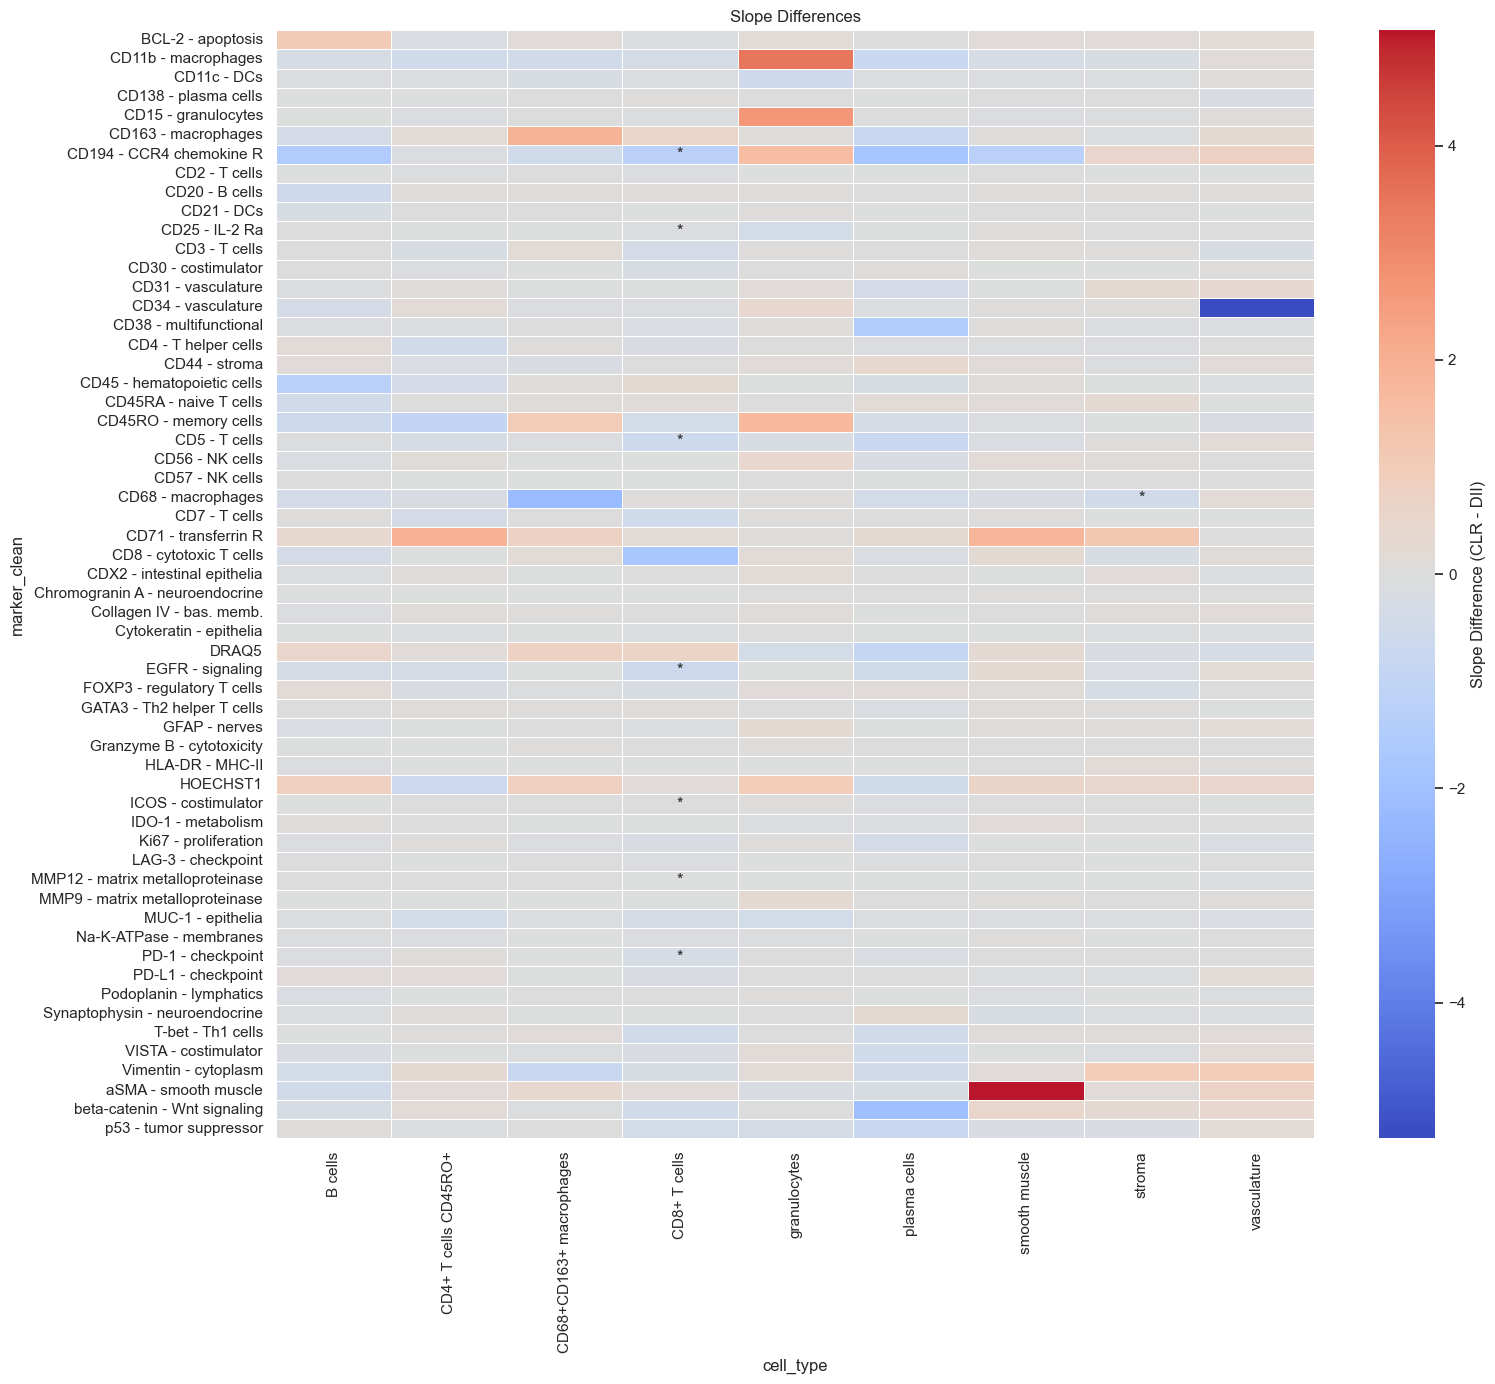

PermissionError: [Errno 13] Permission denied: 'Supplementary_Table_S6_Spatial_Gradient.xlsx'

In [4]:
# ==============================
# IMPORTS
# ==============================
import pandas as pd
import numpy as np
from scipy.spatial import cKDTree
from scipy.stats import linregress, mannwhitneyu
from statsmodels.stats.multitest import multipletests
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.stats import ttest_ind

sns.set(style="whitegrid")

# ==============================
# LOAD DATA
# ==============================
df = pd.read_csv("CRC_clusters_neighborhoods_markers.csv")

df["group_label"] = df["groups"].map({1: "CLR", 2: "DII"})
df = df[~df['ClusterName'].isin(['dirt', 'undefined'])]

# ==============================
# DEFINE TUMOR CELLS
# ==============================
df["is_tumor"] = df["ClusterName"].str.lower().str.contains("tumor")

# ==============================
# PROXIMITY (PER SPOT, FIXED)
# ==============================
df["proximity_to_tumor"] = np.nan
k = 5

for spot in df["spots"].unique():
    sub = df[df["spots"] == spot]
    tumor = sub[sub["is_tumor"]]

    if len(tumor) == 0:
        continue

    tree = cKDTree(tumor[["X:X", "Y:Y"]].values)

    k_use = min(k, len(tumor))  # 🔥 critical fix

    dist, _ = tree.query(sub[["X:X", "Y:Y"]].values, k=k_use)

    if k_use > 1:
        dist = dist.mean(axis=1)

    # dist[np.isinf(dist)] = np.nan

    df.loc[sub.index, "proximity_to_tumor"] = -dist

# ==============================
# REMOVE TUMOR CELLS
# ==============================
df_non_tumor = df[~df["is_tumor"]].copy()

# ==============================
# MARKERS
# ==============================
marker_cols = [c for c in df.columns if "Cyc_" in c and "ch_" in c]
marker_name_map = {c: c.split(":")[0] for c in marker_cols}

# ==============================
# FILTER CELL TYPES
# ==============================
valid_cell_types = [
    ct for ct in df_non_tumor["ClusterName"].unique()
    if len(df_non_tumor[df_non_tumor["ClusterName"] == ct]) >= 100
]

# ==============================
# STEP 1: PER-SPOT SLOPES
# ==============================
results_spot = []

for spot in tqdm(df_non_tumor["spots"].unique(), desc="Per-spot"):

    df_spot = df_non_tumor[df_non_tumor["spots"] == spot]
    group = df_spot["group_label"].iloc[0]

    for ct in valid_cell_types:

        sub = df_spot[df_spot["ClusterName"] == ct]

        if len(sub) < 10:
            continue

        proximity = sub["proximity_to_tumor"].values

        for marker in marker_cols:

            y = sub[marker].values

            valid = ~np.isnan(proximity) & ~np.isnan(y)

            X = proximity[valid]
            yv = y[valid]

            if len(X) < 30:
                continue

            if np.std(X) < 1e-6:
                continue

            try:
                slope, _, _, p, _ = linregress(X, yv)

                results_spot.append({
                    "spot": spot,
                    "group": group,
                    "cell_type": ct,
                    "marker": marker,
                    "marker_clean": marker_name_map[marker],
                    "slope": slope
                })

            except:
                continue

spot_df = pd.DataFrame(results_spot)

# ==============================
# STEP 2: COMPARE CLR vs DII
# ==============================
results_compare = []

for (ct, marker), sub in tqdm(
    spot_df.groupby(["cell_type", "marker_clean"]),
    desc="Group comparison"
):

    clr_vals = sub[sub["group"] == "CLR"]["slope"]
    dii_vals = sub[sub["group"] == "DII"]["slope"]

    if len(clr_vals) < 3 or len(dii_vals) < 3:
        continue

    try:
        stat, p = mannwhitneyu(clr_vals, dii_vals, alternative="two-sided")

        results_compare.append({
            "cell_type": ct,
            "marker_clean": marker,
            "mean_clr": clr_vals.mean(),
            "mean_dii": dii_vals.mean(),
            "slope_diff": clr_vals.mean() - dii_vals.mean(),
            "p_value": p,
            "n_clr": len(clr_vals),
            "n_dii": len(dii_vals)
        })

    except:
        continue

compare_df = pd.DataFrame(results_compare)

# ==============================
# FDR CORRECTION
# ==============================
compare_df["adj_p_value"] = multipletests(compare_df["p_value"], method="fdr_bh")[1]
compare_df["neglog10_q"] = -np.log10(compare_df["adj_p_value"] + 1e-10)

min_n = 10

compare_df = compare_df[
    (compare_df["n_clr"] >= min_n) &
    (compare_df["n_dii"] >= min_n)
]

# ==============================
# PLOT: DOT PLOT
# ==============================
def dotplot(compare_df):

    df_plot = compare_df.copy()

    # Optional: sort markers for cleaner display
    df_plot = df_plot.sort_values("marker_clean")

    # Create figure
    fig, axes = plt.subplots(1, 2, figsize=(24, 14), sharey=True)

    # 🔵 CLR plot
    scatter1 = sns.scatterplot(
        data=df_plot,
        x="mean_clr",
        y="marker_clean",
        hue="cell_type",
        size="neglog10_q",
        sizes=(50, 300),
        alpha=0.8,
        ax=axes[0]
    )

    axes[0].axvline(0, color="black")
    axes[0].set_title("CLR: Spatial slopes")
    axes[0].set_xlabel("Mean slope (CLR)")
    axes[0].set_ylabel("Marker")

    # 🔴 DII plot
    sns.scatterplot(
        data=df_plot,
        x="mean_dii",
        y="marker_clean",
        hue="cell_type",
        size="neglog10_q",
        sizes=(50, 300),
        alpha=0.8,
        legend=False,  # prevent duplicate legend
        ax=axes[1]
    )

    axes[1].axvline(0, color="black")
    axes[1].set_title("DII: Spatial slopes")
    axes[1].set_xlabel("Mean slope (DII)")
    axes[1].set_ylabel("")

    # -------------------------------
    # ✅ Create ONE shared legend outside
    # -------------------------------
    handles, labels = axes[0].get_legend_handles_labels()

    # Remove default legend from axes
    axes[0].legend_.remove()

    # Add figure-level legend
    fig.legend(
        handles,
        labels,
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0,
        title="Cell type / Significance"
    )

    # Adjust layout to make space for legend
    plt.subplots_adjust(right=0.8)

    plt.tight_layout()
    plt.savefig("CLR_vs_DII_Dotplots_Spatial_Gradient.png", dpi=600, bbox_inches='tight')
    plt.show()

dotplot(compare_df)

# ==============================
# HEATMAP
# ==============================
def heatmap(compare_df):

    pivot = compare_df.pivot(
        index="marker_clean",
        columns="cell_type",
        values="slope_diff"
    )

    sig = compare_df.pivot(
        index="marker_clean",
        columns="cell_type",
        values="adj_p_value"
    )

    annot = sig.copy().astype(str)
    annot[sig < 0.05] = "*"
    annot[sig >= 0.05] = ""

    plt.figure(figsize=(16, 14))

    sns.heatmap(
        pivot,
        cmap="coolwarm",
        center=0,
        annot=annot,
        fmt="",
        linewidths=0.5,
        cbar_kws={"label": "Slope Difference (CLR - DII)"}
    )

    plt.title("Slope Differences")
    plt.tight_layout()
    plt.savefig("Heatmap_Spatial_Gradient.png", dpi=600)
    plt.show()

heatmap(compare_df)

# ==============================
# SAVE RESULTS
# ==============================
compare_df["abs_slope_diff"] = compare_df["slope_diff"].abs()
compare_df = compare_df.sort_values("abs_slope_diff", ascending=False)

with pd.ExcelWriter("Supplementary_Table_S6_Spatial_Gradient.xlsx") as writer:
    spot_df.to_excel(writer, sheet_name="Spot_slopes", index=False)
    compare_df.to_excel(writer, sheet_name="Comparison", index=False)


Markers with +ve slope difference in MOST cell types (>70%):
            marker_clean  total_cell_types  pos_slope_count  avg_slope_diff  \
26  CD71 - transferrin R                 9                8        0.732835   
39              HOECHST1                 9                7        0.362238   
0      BCL-2 - apoptosis                 9                7        0.169369   
8         CD20 - B cells                 9                7       -0.022682   

    pct_positive  
26     88.888889  
39     77.777778  
0      77.777778  
8      77.777778  


C:\Users\Mangalam\AppData\Local\Temp\ipykernel_23704\18395814.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=consistency_df.head(15), x="pct_positive", y="marker_clean", palette="viridis")


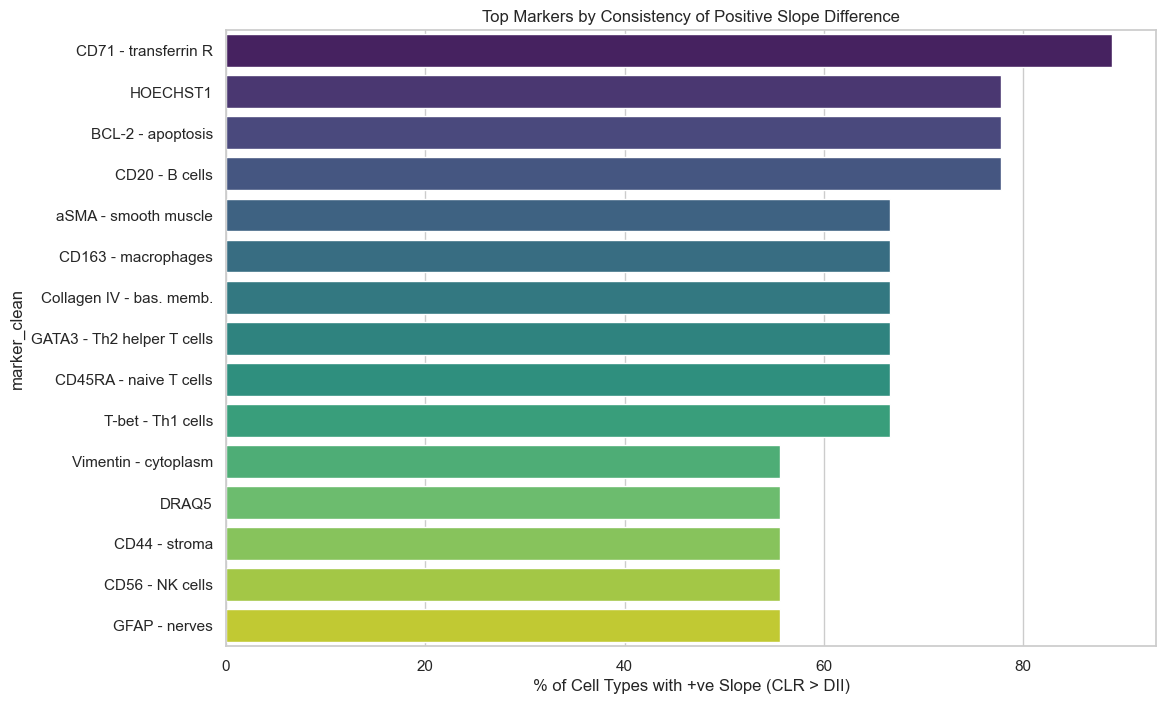

In [7]:
# ==============================
# RANK MARKERS BY CONSISTENCY
# ==============================

# 1. Count total cell types and positive occurrences per marker
consistency_df = compare_df.groupby("marker_clean").agg(
    total_cell_types=('cell_type', 'count'),
    pos_slope_count=('slope_diff', lambda x: (x > 0).sum()),
    avg_slope_diff=('slope_diff', 'mean')
).reset_index()

# 2. Calculate percentage consistency
consistency_df["pct_positive"] = (consistency_df["pos_slope_count"] / consistency_df["total_cell_types"]) * 100

# 3. Sort by percentage and then by the average magnitude of the difference
consistency_df = consistency_df.sort_values(["pct_positive", "avg_slope_diff"], ascending=False)

# 4. Filter for "Most" (e.g., > 70% or whatever threshold you prefer)
most_positive = consistency_df[consistency_df["pct_positive"] > 70]

print("Markers with +ve slope difference in MOST cell types (>70%):")
print(most_positive)

# Optional: Visualization of Consistency
plt.figure(figsize=(12, 8))
sns.barplot(data=consistency_df.head(15), x="pct_positive", y="marker_clean", palette="viridis")
plt.title("Top Markers by Consistency of Positive Slope Difference")
plt.xlabel("% of Cell Types with +ve Slope (CLR > DII)")
plt.show()
